# 🔶 Colab C — PyTorch nn.Module: Class-Based Neural Network
**Uses nn.Linear, nn.ReLU, nn.Tanh, optim.Adam, nn.MSELoss**

In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
torch.manual_seed(42); np.random.seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


## 📊 Section 1 — Data

In [2]:
N=1000
x1=np.random.uniform(-2,2,(N,1)); x2=np.random.uniform(-2,2,(N,1)); x3=np.random.uniform(-2,2,(N,1))
y=2*x1**2+3*x2*x3+np.sin(x1*x2)+0.5*x3**2+np.random.normal(0,0.1,(N,1))
X=np.hstack([x1,x2,x3])
X_n=(X-X.mean(0))/X.std(0); y_mean,y_std=y.mean(),y.std(); y_n=(y-y_mean)/y_std
sp=int(0.8*N)
def t(a): return torch.tensor(a,dtype=torch.float32,device=DEVICE)
Xtr,Xte=t(X_n[:sp]),t(X_n[sp:]); Ytr,Yte=t(y_n[:sp]),t(y_n[sp:])
print(f'Train {Xtr.shape}, Test {Xte.shape}')

Train torch.Size([800, 3]), Test torch.Size([200, 3])


## 🏗️ Section 2 — NeuralNet Class (nn.Module)

In [3]:
class NeuralNet(nn.Module):
    """3-layer deep network: Input(3)→64→32→16→Output(1)"""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()
        self._init_weights()

    def _init_weights(self):
        # He initialization for ReLU layers
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.relu(self.fc1(x))   # 3  → 64
        x = self.relu(self.fc2(x))   # 64 → 32
        x = self.tanh(self.fc3(x))   # 32 → 16
        return self.out(x)           # 16 → 1

model = NeuralNet().to(DEVICE)
print(model)
print(f'Total params: {sum(p.numel() for p in model.parameters())}')

NeuralNet(
  (fc1): Linear(in_features=3, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (tanh): Tanh()
)
Total params: 2881


## 🏋️ Section 3 — Training Loop

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# FIXED — works on all modern PyTorch versions
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',factor=0.5,patience=50)
EPOCHS, BATCH = 1000, 64
tr_hist, va_hist = [], []

from torch.utils.data import TensorDataset, DataLoader
ds = TensorDataset(Xtr, Ytr)
dl = DataLoader(ds, batch_size=BATCH, shuffle=True)

for epoch in range(EPOCHS):
    model.train()
    ep_loss = 0
    for Xb, Yb in dl:
        optimizer.zero_grad()          # clear old gradients
        pred = model(Xb)               # forward pass
        loss = criterion(pred, Yb)     # compute MSE loss
        loss.backward()                # backpropagation
        optimizer.step()               # update weights
        ep_loss += loss.item()

    model.eval()
    with torch.no_grad():
        vl = criterion(model(Xte), Yte).item()
    ep_loss /= len(dl)
    tr_hist.append(ep_loss); va_hist.append(vl)
    scheduler.step(vl)
    if (epoch+1)%100==0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Ep {epoch+1:4d} | Train: {ep_loss:.5f} | Val: {vl:.5f} | LR: {lr_now:.6f}')

Ep  100 | Train: 0.00359 | Val: 0.00480 | LR: 0.001000
Ep  200 | Train: 0.00170 | Val: 0.00341 | LR: 0.001000
Ep  300 | Train: 0.00110 | Val: 0.00250 | LR: 0.001000
Ep  400 | Train: 0.00085 | Val: 0.00243 | LR: 0.001000
Ep  500 | Train: 0.00064 | Val: 0.00184 | LR: 0.000500
Ep  600 | Train: 0.00040 | Val: 0.00178 | LR: 0.000250
Ep  700 | Train: 0.00035 | Val: 0.00164 | LR: 0.000063
Ep  800 | Train: 0.00031 | Val: 0.00163 | LR: 0.000016
Ep  900 | Train: 0.00031 | Val: 0.00162 | LR: 0.000004
Ep 1000 | Train: 0.00030 | Val: 0.00162 | LR: 0.000001


## 📈 Section 4 — Results + Model Save/Load

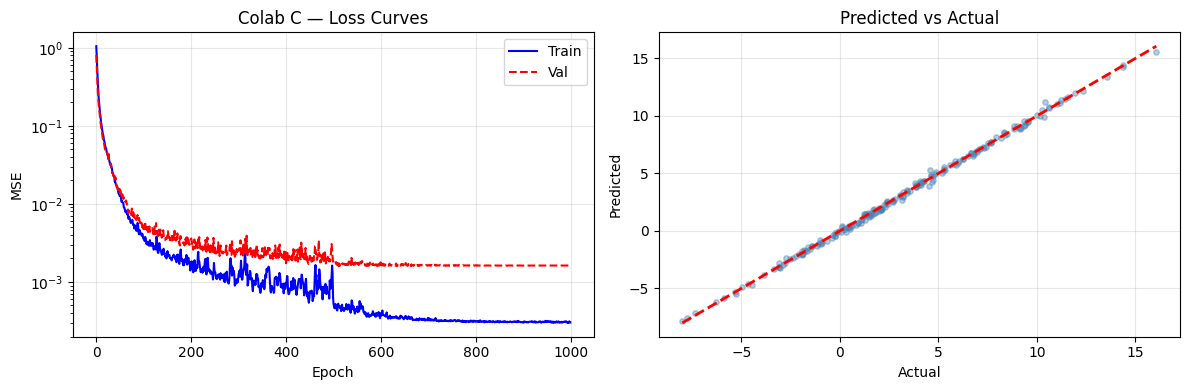

Test MSE: 0.0372
Model saved and reloaded successfully


In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].semilogy(tr_hist,'b',label='Train'); axes[0].semilogy(va_hist,'r--',label='Val')
axes[0].set(title='Colab C — Loss Curves',xlabel='Epoch',ylabel='MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

model.eval()
with torch.no_grad():
    yp=(model(Xte).cpu().numpy()*y_std+y_mean)
    yt=(Yte.cpu().numpy()*y_std+y_mean)
axes[1].scatter(yt,yp,alpha=0.4,s=15,color='steelblue')
mn,mx=yt.min(),yt.max()
axes[1].plot([mn,mx],[mn,mx],'r--',lw=2)
axes[1].set(title='Predicted vs Actual',xlabel='Actual',ylabel='Predicted')
axes[1].grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Test MSE: {((yp-yt)**2).mean():.4f}')

# Save & reload
torch.save(model.state_dict(),'colab_c_model.pt')
m2=NeuralNet().to(DEVICE); m2.load_state_dict(torch.load('colab_c_model.pt'))
print('Model saved and reloaded successfully')